Setup and Libraries

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Set visualization style
sns.set_style(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Analysis Environment loaded successfully.")

Analysis Environment loaded successfully.


Load the Training Set

In [3]:
train_path = "../data/processed/train.csv"

if not os.path.exists(train_path):
    raise FileNotFoundError(f"Training data not found at: {train_path}. Please run the data ingestion script first.")

df = pd.read_csv(train_path)
print(f"Training data loaded successfully. Total Records: {df.shape[0]}, Total Features: {df.shape[1]}")
df.head(5)

Training data loaded successfully. Total Records: 5634, Total Features: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,Yes,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.7,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No


Uncover the Hidden Data Traps

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   str    
 1   gender            5634 non-null   str    
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   str    
 4   Dependents        5634 non-null   str    
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   str    
 7   MultipleLines     5634 non-null   str    
 8   InternetService   5634 non-null   str    
 9   OnlineSecurity    5634 non-null   str    
 10  OnlineBackup      5634 non-null   str    
 11  DeviceProtection  5634 non-null   str    
 12  TechSupport       5634 non-null   str    
 13  StreamingTV       5634 non-null   str    
 14  StreamingMovies   5634 non-null   str    
 15  Contract          5634 non-null   str    
 16  PaperlessBilling  5634 non-null   str    
 17  Paymen

In [5]:
blank_rows = df[df['TotalCharges'].str.strip() == ""]
print(f"\nFound {len(blank_rows)} rows with empty string values in 'TotalCharges'.")


Found 8 rows with empty string values in 'TotalCharges'.


Clean the Hidden Type Traps

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(r'^\s*$', np.nan, regex=True))

In [9]:
#Check the missing values across the dataset
print("Missing Values Count:\n")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing Values Count:

TotalCharges    8
dtype: int64


In [17]:
median_total_charges = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)

print(f"Remaining missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

Remaining missing values in TotalCharges: 0


Analyze Target Class Imbalance

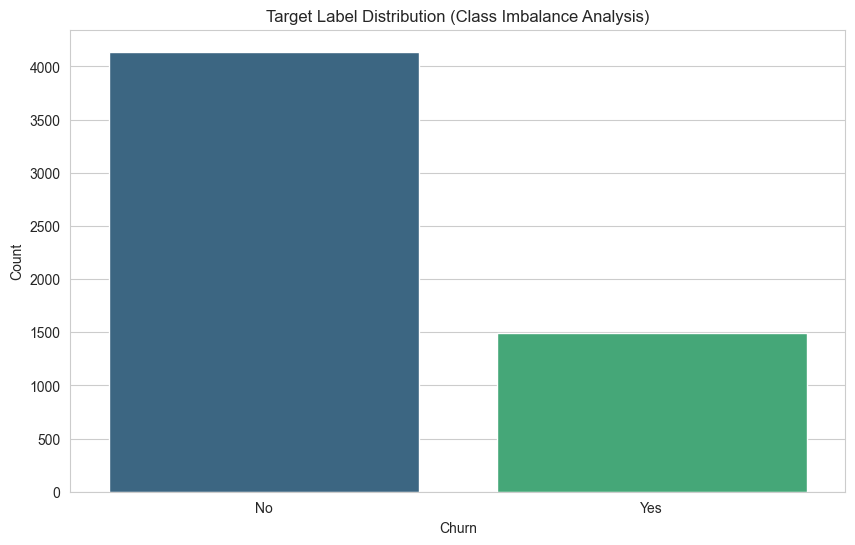

Class Ratios:
No Churn: 73.46%
Churn: 26.54%


In [20]:
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='Churn', hue='Churn', palette='viridis', legend=False)
plt.title("Target Label Distribution (Class Imbalance Analysis)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(f"Class Ratios:\nNo Churn: {churn_rate['No']:.2f}%\nChurn: {churn_rate['Yes']:.2f}%")

Check Continuous Feature Correlations

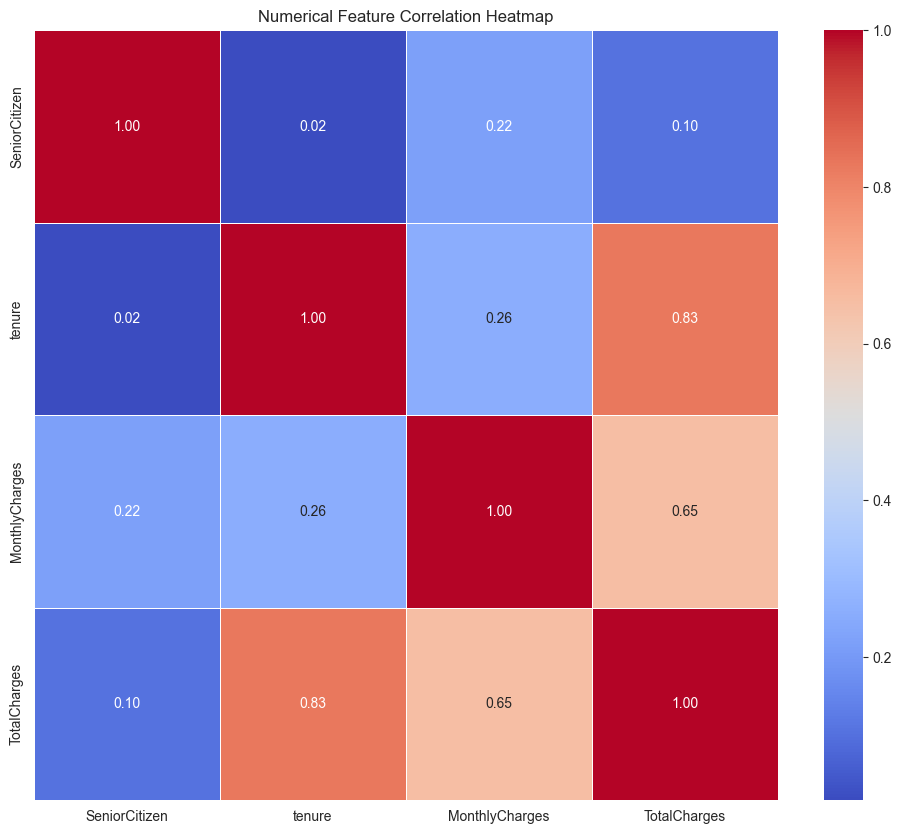

In [24]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Numerical Feature Correlation Heatmap")


#Save chart into output directory
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/numerical_correlation_heatmap.png", bbox_inches='tight')
plt.show()